# 🤚 Hand Gesture Recognition using CNN
> **SkillCraft Technology — Machine Learning Internship | Task 4**
>
> Dataset: [LeapGestRecog — Kaggle](https://www.kaggle.com/datasets/gti-upm/leapgestrecog)
>
> Model: TensorFlow / Keras Convolutional Neural Network

---

## 📦 Step 0 — Install & Import Libraries

In [1]:
# ── Standard library ──
import os
import sys
import warnings
import random
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

# ── Numerical / imaging ──
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Machine learning ──
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)

# ── TensorFlow / Keras ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'TF      : {tf.__version__}')
print(f'OpenCV  : {cv2.__version__}')
print(f'GPUs    : {tf.config.list_physical_devices("GPU")}')

Python  : 3.12.10
NumPy   : 1.26.4
TF      : 2.16.1
OpenCV  : 4.11.0
GPUs    : []


In [2]:
from pathlib import Path

p = Path('dataset/leapGestRecog')

print("Folders:")
for x in sorted(p.iterdir()):
    if x.is_dir():
        print(x.name)

Folders:
00
01
02
03
04
05
06
07
08
09


## ⚙️ Step 1 — Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURATION — edit DATASET_DIR to point at your downloaded dataset folder
# ─────────────────────────────────────────────────────────────────────────────

# Root of the unzipped Kaggle archive (should contain sub-folders 00/ through 09/,
# each with 10 gesture sub-folders)
DATASET_DIR = Path('dataset/leapGestRecog')

IMG_SIZE   = 128         # resize all images to IMG_SIZE × IMG_SIZE
BATCH_SIZE = 32
EPOCHS     = 2
LR         = 1e-3        # initial learning rate
TEST_SPLIT = 0.20        # 80 / 20 train-test
VAL_SPLIT  = 0.10        # 10% of train → validation

MODEL_DIR  = Path('model')
OUT_DIR    = Path('outputs')
MODEL_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / 'hand_gesture_model.h5'

# Gesture class definitions (folder name → display label)
GESTURE_CLASSES = [
    '01_palm', '02_l', '03_fist', '04_fist_moved',
    '05_thumb', '06_index', '07_ok', '08_palm_moved',
    '09_c', '10_down'
]
NUM_CLASSES = len(GESTURE_CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(GESTURE_CLASSES)}

print(f'IMG_SIZE   : {IMG_SIZE}×{IMG_SIZE}')
print(f'Classes    : {NUM_CLASSES}')
print(f'Dataset dir: {DATASET_DIR}')

IMG_SIZE   : 128×128
Classes    : 10
Dataset dir: dataset\leapGestRecog


In [4]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nDataset exists?")
print(Path("dataset/dataset task 4/leapGestRecog").exists())

print("\nFolders found:")
for p in Path(".").rglob("leapGestRecog"):
    print(p)

Current working directory:
c:\Users\sanuh\Downloads\SCT_ML_INTERNSHIP_SANU\SCT_ML_4\skillcraft_task4_hand_gesture_recognition\skillcraft_task4_hand_gesture_recognition

Dataset exists?
False

Folders found:
dataset\leapGestRecog


In [5]:
print(DATASET_DIR)
print(DATASET_DIR.exists())

dataset\leapGestRecog
True


In [6]:
print(DATASET_DIR)

dataset\leapGestRecog


## 📥 Step 2 — Load Dataset

Loading dataset …
Shape: (20000, 128, 128, 3)
Dtype: float32
Min: 0.0
Max: 1.0


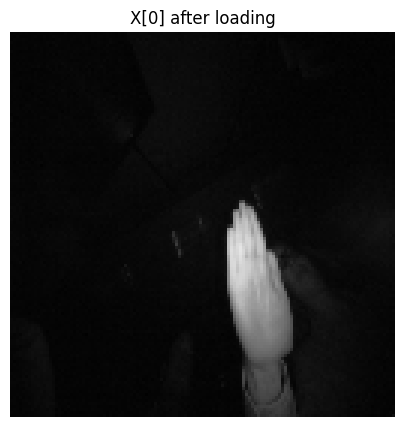

X shape : (20000, 128, 128, 3)  dtype=float32
y shape : (20000,)  unique labels=[0 1 2 3 4 5 6 7 8 9]
Class distribution: Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000})


In [7]:
def load_dataset(root: Path, img_size: int = IMG_SIZE):
    """
    Walk the LeapGestRecog directory tree and load all images.

    Expected structure:
        root/
        ├── 00/               ← subject 00
        │   ├── 01_palm/
        │   │   ├── frame_00_001_0001.png
        │   │   └── ...
        │   └── ...
        └── 09/               ← subject 09

    Returns
    -------
    X : np.ndarray  shape (N, img_size, img_size, 3)  dtype float32  in [0,1]
    y : np.ndarray  shape (N,)                        dtype int
    """
    X, y = [], []
    missing_classes = set(GESTURE_CLASSES)  # track which we actually find

    if not root.exists():
        print(f'[WARNING] Dataset directory not found: {root}')
        print('          Generating SYNTHETIC dataset for demonstration …')
        return _generate_synthetic_dataset(img_size)

    for subject_dir in sorted(root.iterdir()):
        if not subject_dir.is_dir():
            continue
        for gesture_dir in sorted(subject_dir.iterdir()):
            if not gesture_dir.is_dir():
                continue
            gesture_name = gesture_dir.name  # e.g. '01_palm'
            if gesture_name not in CLASS_TO_IDX:
                continue
            label = CLASS_TO_IDX[gesture_name]
            missing_classes.discard(gesture_name)
            for img_path in sorted(gesture_dir.glob('*.png')) + \
                            sorted(gesture_dir.glob('*.jpg')) + \
                            sorted(gesture_dir.glob('*.jpeg')):
                img = cv2.imread(str(img_path))
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                img = img.astype(np.float32) / 255.0
                img = np.clip(img, 0, 1)  # ensure valid range [0, 1]
                X.append(img)
                y.append(label)

    if missing_classes:
        print(f'[INFO] Classes not found in dataset: {missing_classes}')

    return np.array(X), np.array(y)


def _generate_synthetic_dataset(img_size: int, n_per_class: int = 200):
    """
    Fallback: generate simple synthetic images so the notebook can run
    end-to-end without the real dataset.  Each class gets a unique
    gradient+noise pattern so the model can still learn to separate them.
    """
    rng = np.random.default_rng(SEED)
    X, y = [], []
    for label in range(NUM_CLASSES):
        for _ in range(n_per_class):
            base_color = np.array([
                (label * 25) % 256,
                (label * 50 + 80) % 256,
                (200 - label * 20) % 256,
            ], dtype=np.float32) / 255.0
            img = np.tile(base_color, (img_size, img_size, 1)).astype(np.float32)
            # add structured noise to make classes distinguishable
            img += rng.normal(0, 0.08, img.shape).astype(np.float32)
            img = np.clip(img, 0, 1)
            X.append(img)
            y.append(label)
    print(f'[SYNTHETIC] Generated {len(X)} images ({n_per_class} per class)')
    return np.array(X), np.array(y)


print('Loading dataset …')
X, y = load_dataset(DATASET_DIR)
print("Shape:", X.shape)
print("Dtype:", X.dtype)
print("Min:", X.min())
print("Max:", X.max())

plt.figure(figsize=(5,5))
plt.imshow(X[0])
plt.title("X[0] after loading")
plt.axis("off")
plt.show()
print(f'X shape : {X.shape}  dtype={X.dtype}')
print(f'y shape : {y.shape}  unique labels={np.unique(y)}')
print(f'Class distribution: {Counter(y)}')

In [8]:
print(f'X shape : {X.shape}  dtype={X.dtype}')
print(f'y shape : {y.shape}  unique labels={np.unique(y)}')
print(f'Class distribution: {Counter(y)}')

X shape : (20000, 128, 128, 3)  dtype=float32
y shape : (20000,)  unique labels=[0 1 2 3 4 5 6 7 8 9]
Class distribution: Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000})


In [9]:
print(GESTURE_CLASSES)

['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [10]:
for subject_dir in sorted(DATASET_DIR.iterdir()):
    if subject_dir.is_dir():
        print("\nSubject:", subject_dir.name)

        for gesture_dir in sorted(subject_dir.iterdir()):
            if gesture_dir.is_dir():
                print("  ", gesture_dir.name)


Subject: 00
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 01
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 02
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 03
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 04
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 05
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 06
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   08_palm_moved
   09_c
   10_down

Subject: 07
   01_palm
   02_l
   03_fist
   04_fist_moved
   05_thumb
   06_index
   07_ok
   0

In [11]:
from pathlib import Path

root = Path("dataset/leapGestRecog")

for subject in sorted(root.iterdir()):
    if subject.is_dir():
        print(f"\n{subject.name}:")
        for gesture in sorted(subject.iterdir()):
            if gesture.is_dir():
                print("   ", gesture.name)
        break


00:
    01_palm
    02_l
    03_fist
    04_fist_moved
    05_thumb
    06_index
    07_ok
    08_palm_moved
    09_c
    10_down


## 🔍 Step 3 — Exploratory Data Analysis

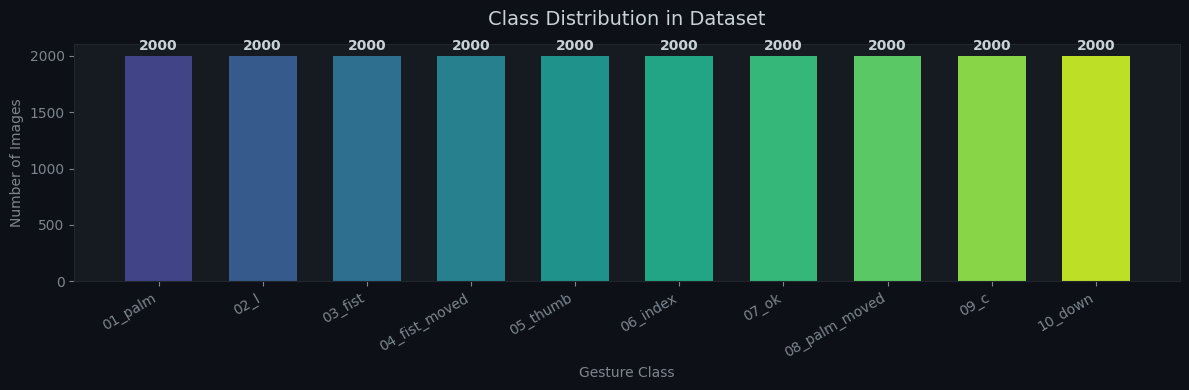

[SAVED] outputs/class_distribution.png


In [12]:
# ── 3.1  Class distribution bar chart ────────────────────────────────────────
counts = Counter(y)
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

bars = ax.bar(
    [GESTURE_CLASSES[i] for i in range(NUM_CLASSES)],
    [counts[i] for i in range(NUM_CLASSES)],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, NUM_CLASSES)),
    edgecolor='none', linewidth=0, width=0.65
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', va='bottom',
            color='#c9d1d9', fontsize=10, fontweight='bold')

ax.set_title('Class Distribution in Dataset', color='#c9d1d9', fontsize=14, pad=14)
ax.set_xlabel('Gesture Class', color='#7d8590')
ax.set_ylabel('Number of Images', color='#7d8590')
ax.tick_params(colors='#7d8590')
ax.spines[:].set_color('#21262d')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR/'class_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'[SAVED] {OUT_DIR}/class_distribution.png')

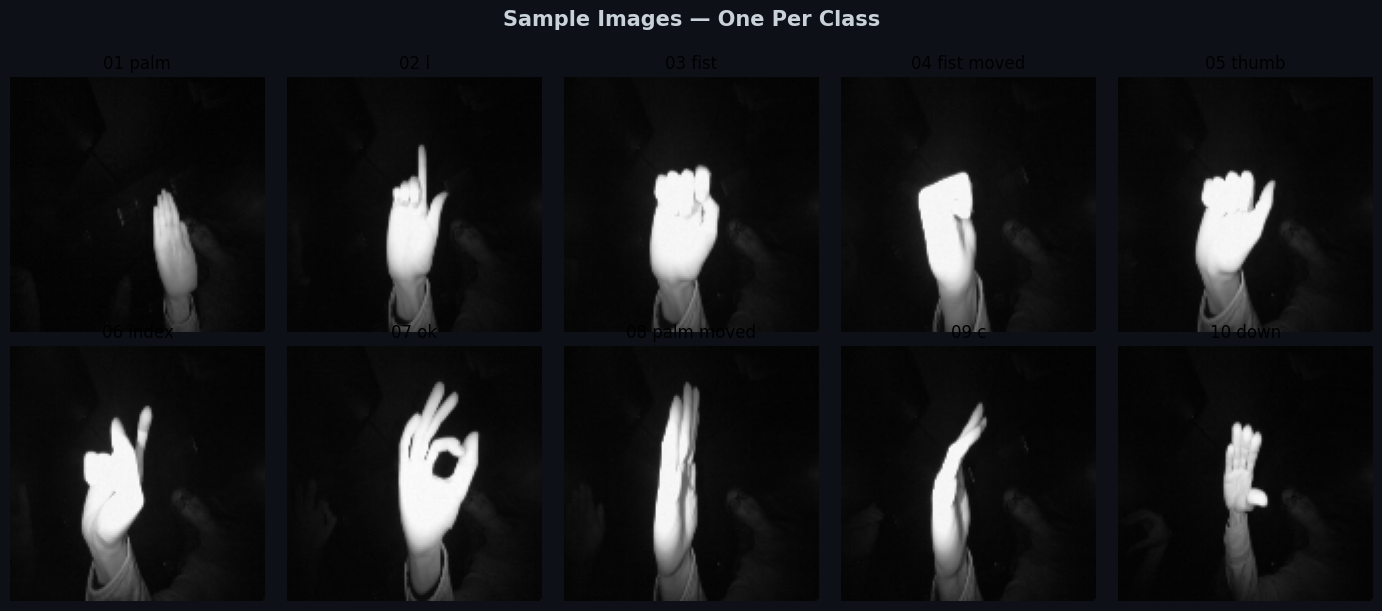

[SAVED] outputs/sample_images.png


In [13]:
# ── 3.2  Sample images grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Sample Images — One Per Class', color='#c9d1d9',
             fontsize=15, fontweight='bold', y=1.01)

for ax, cls_name in zip(axes.flat, GESTURE_CLASSES):
    label = CLASS_TO_IDX[cls_name]

    indices = np.where(y == label)[0]

    if len(indices) == 0:
        ax.text(
            0.5, 0.5,
            "No Image",
            ha="center",
            va="center",
            color="white"
        )
        ax.axis("off")
        continue

    idx = indices[0]

    ax.imshow(X[idx], cmap="gray")
    ax.set_title(cls_name.replace("_", " "))
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR/'sample_images.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'[SAVED] {OUT_DIR}/sample_images.png')

## ✂️ Step 4 — Train / Validation / Test Split

In [14]:
# ── Stratified 80 / 20 split ─────────────────────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

# ── Further split train_val into train / val ──────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_train_val,
    random_state=SEED
)

# ── One-hot encode labels ─────────────────────────────────────────────────────
y_train_ohe = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_ohe   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_ohe  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f'Train      : {X_train.shape}  {y_train.shape}')
print(f'Validation : {X_val.shape}    {y_val.shape}')
print(f'Test       : {X_test.shape}   {y_test.shape}')

Train      : (14000, 128, 128, 3)  (14000,)
Validation : (2000, 128, 128, 3)    (2000,)
Test       : (4000, 128, 128, 3)   (4000,)


## 🔄 Step 5 — Data Augmentation

X_train shape: (14000, 128, 128, 3)
X_train dtype: float32
Min: 0.0
Max: 1.0


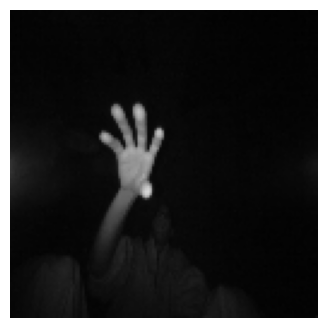

In [15]:
print("X_train shape:", X_train.shape)
print("X_train dtype:", X_train.dtype)
print("Min:", X_train.min())
print("Max:", X_train.max())

plt.figure(figsize=(4,4))
plt.imshow(X_train[0])
plt.axis("off")
plt.show()

In [16]:
print("X_train dtype:", X_train.dtype)
print("X_train min/max:", X_train.min(), X_train.max())
print("Sample image shape:", X_train[0].shape)

X_train dtype: float32
X_train min/max: 0.0 1.0
Sample image shape: (128, 128, 3)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

In [ ]:
# Visualise augmentation examples
sample_img = X_train[0:1].copy()

# Normalize to 0-1 if values are in 0-255 range
if sample_img.max() > 1.0:
    sample_img = sample_img / 255.0

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

aug_iter = datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Augmentation Examples (one source image → 10 variants)',
             color='#c9d1d9', fontsize=13)
for ax in axes.flat:
    aug_img = next(aug_iter)[0]
    aug_img = np.clip(aug_img, 0, 1)
    ax.imshow(aug_img, cmap='gray')   # ← added cmap='gray' for grayscale
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Data augmentation configured ✔')

NameError: name 'datagen' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("dtype:", X_train.dtype)
print("min:", X_train.min())
print("max:", X_train.max())
print("shape:", X_train.shape)
print("unique values sample:", np.unique(X_train[0])[:10])

# Force display the raw image
plt.figure(facecolor='white')
img = X_train[0]
print("img shape:", img.shape)

# If 4D squeeze it
if img.ndim == 3 and img.shape[-1] == 1:
    img = img.squeeze()

plt.imshow(img, cmap='gray', vmin=X_train.min(), vmax=X_train.max())
plt.colorbar()
plt.title("Raw image debug")
plt.show()

## 🏗️ Step 6 — Build CNN Model

In [ ]:
def build_gesture_cnn(img_size: int = IMG_SIZE, num_classes: int = NUM_CLASSES):
    """
    Build a compact but powerful CNN for hand gesture recognition.

    Architecture:
      Input (64×64×3)
      → [Conv2D(32) → BN → MaxPool → Dropout] × 1
      → [Conv2D(64) → BN → MaxPool → Dropout] × 1
      → [Conv2D(128) → BN → MaxPool → Dropout] × 1
      → GlobalAveragePooling2D
      → Dense(256, relu) → Dropout(0.5)
      → Dense(num_classes, softmax)
    """
    inp = keras.Input(shape=(img_size, img_size, 3), name='input_image')

    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Block 3 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    x = layers.Dropout(0.25, name='drop3')(x)

    # ── Head ─────────────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.Dropout(0.50, name='drop_fc')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='HandGestureCNN')
    return model


model = build_gesture_cnn()
model.summary(line_length=80)

## 🎯 Step 7 — Compile & Train

In [ ]:
# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Save the best model (highest val_accuracy)
    ModelCheckpoint(
        str(MODEL_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    # Halve LR if val_loss plateaus for 5 epochs
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    # Stop training if val_accuracy doesn't improve for 10 epochs
    EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
]

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    datagen.flow(X_train, y_train_ohe, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_ohe),
    callbacks=callbacks,
    verbose=1,
)

print(f'\n✅ Best model saved to {MODEL_PATH}')

## 📈 Step 8 — Training Curves

In [ ]:
def plot_training_curves(history):
    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    # ── Accuracy curve ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    ax.plot(epochs_ran, history.history['accuracy'],
            color='#58a6ff', linewidth=2.5, label='Train Accuracy', marker='o', markersize=4)
    ax.plot(epochs_ran, history.history['val_accuracy'],
            color='#3fb950', linewidth=2.5, label='Val Accuracy',
            linestyle='--', marker='s', markersize=4)

    ax.set_title('Training & Validation Accuracy', color='#c9d1d9', fontsize=14, pad=12)
    ax.set_xlabel('Epoch', color='#7d8590')
    ax.set_ylabel('Accuracy', color='#7d8590')
    ax.tick_params(colors='#7d8590')
    ax.spines[:].set_color('#21262d')
    ax.grid(color='#21262d', linewidth=0.7)
    ax.legend(facecolor='#0d1117', labelcolor='#c9d1d9', edgecolor='#30363d')
    plt.tight_layout()
    plt.savefig(OUT_DIR/'accuracy_curve.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print(f'[SAVED] {OUT_DIR}/accuracy_curve.png')

    # ── Loss curve ───────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    ax.plot(epochs_ran, history.history['loss'],
            color='#f85149', linewidth=2.5, label='Train Loss', marker='o', markersize=4)
    ax.plot(epochs_ran, history.history['val_loss'],
            color='#d29922', linewidth=2.5, label='Val Loss',
            linestyle='--', marker='s', markersize=4)

    ax.set_title('Training & Validation Loss', color='#c9d1d9', fontsize=14, pad=12)
    ax.set_xlabel('Epoch', color='#7d8590')
    ax.set_ylabel('Loss', color='#7d8590')
    ax.tick_params(colors='#7d8590')
    ax.spines[:].set_color('#21262d')
    ax.grid(color='#21262d', linewidth=0.7)
    ax.legend(facecolor='#0d1117', labelcolor='#c9d1d9', edgecolor='#30363d')
    plt.tight_layout()
    plt.savefig(OUT_DIR/'loss_curve.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print(f'[SAVED] {OUT_DIR}/loss_curve.png')


plot_training_curves(history)

## 📊 Step 9 — Evaluation on Test Set

In [ ]:
# ── Load the best saved model (from ModelCheckpoint) ─────────────────────────
best_model = tf.keras.models.load_model(MODEL_PATH)

# ── Evaluate ─────────────────────────────────────────────────────────────────
test_loss, test_acc = best_model.evaluate(X_test, y_test_ohe, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc*100:.2f}%')

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Classification report ─────────────────────────────────────────────────────
print('\n── Classification Report ───────────────────────────────────────────────')
print(classification_report(
    y_test, y_pred, target_names=GESTURE_CLASSES, digits=4
))

## 🗂️ Step 10 — Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    cmap='Blues',
    xticklabels=[c.replace('_', '\n') for c in GESTURE_CLASSES],
    yticklabels=[c.replace('_', '\n') for c in GESTURE_CLASSES],
    linewidths=0.5, linecolor='#21262d',
    ax=ax,
    annot_kws={'size': 8, 'color': 'white'},
)

ax.set_title('Normalised Confusion Matrix', color='#c9d1d9', fontsize=15, pad=16)
ax.set_xlabel('Predicted Label', color='#7d8590', fontsize=11)
ax.set_ylabel('True Label',      color='#7d8590', fontsize=11)
ax.tick_params(colors='#7d8590', labelsize=8)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='#7d8590')
cbar.ax.yaxis.label.set_color('#7d8590')

plt.tight_layout()
plt.savefig(OUT_DIR/'confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(f'[SAVED] {OUT_DIR}/confusion_matrix.png')

## 🖼️ Step 11 — Sample Predictions

In [ ]:
# Pick 20 random test images
rng    = np.random.default_rng(SEED)
idxs   = rng.choice(len(X_test), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Sample Predictions (Green = Correct  |  Red = Wrong)',
             color='#c9d1d9', fontsize=14, fontweight='bold', y=1.01)

for ax, idx in zip(axes.flat, idxs):
    true_lbl = y_test[idx]
    pred_lbl = y_pred[idx]
    conf     = y_pred_probs[idx][pred_lbl]
    correct  = (true_lbl == pred_lbl)

    ax.imshow(X_test[idx])
    ax.axis('off')

    color = '#3fb950' if correct else '#f85149'
    title = (
        f'T: {GESTURE_CLASSES[true_lbl]}\n'
        f'P: {GESTURE_CLASSES[pred_lbl]} ({conf*100:.0f}%)'
    )
    ax.set_title(title, color=color, fontsize=7.5)

    # Highlight border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig(OUT_DIR/'sample_predictions.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print(f'[SAVED] {OUT_DIR}/sample_predictions.png')

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

root = Path("dataset/leapGestRecog")

img_path = next(root.rglob("*.png"))

print("Image:", img_path)

img = cv2.imread(str(img_path))
print("Shape:", img.shape)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
plt.figure(figsize=(4,4))
plt.imshow(X[0])
plt.show()

## 📋 Step 12 — Final Summary

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('╔══════════════════════════════════════════════════════╗')
print('║        HAND GESTURE RECOGNITION — FINAL RESULTS      ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset       : LeapGestRecog ({len(X)} images)         ║')
print(f'║  Input size    : {IMG_SIZE}×{IMG_SIZE} px RGB                      ║')
print(f'║  Classes       : {NUM_CLASSES} gestures                         ║')
print(f'║  Train samples : {len(X_train)}                            ║')
print(f'║  Val samples   : {len(X_val)}                             ║')
print(f'║  Test samples  : {len(X_test)}                             ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Test Accuracy : {test_acc*100:.2f}%                         ║')
print(f'║  Test Loss     : {test_loss:.4f}                            ║')
print(f'║  Precision     : {precision:.4f}                            ║')
print(f'║  Recall        : {recall:.4f}                            ║')
print(f'║  F1-Score      : {f1:.4f}                            ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Model saved   : {MODEL_PATH}      ║')
print('╚══════════════════════════════════════════════════════╝')

---
## ✅ Notebook complete!

All outputs saved to `outputs/`:  
- `accuracy_curve.png`  
- `loss_curve.png`  
- `confusion_matrix.png`  
- `sample_predictions.png`  
- `class_distribution.png`  
- `sample_images.png`

Model saved to `model/hand_gesture_model.h5`.

Run the web app:
```bash
streamlit run app.py
```